<a href="https://colab.research.google.com/github/iftode/ml-product-category-classification-/blob/main/notebooks/product_category_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Product Category Classification

This notebook contains the full analysis, preprocessing, feature engineering, model training and evaluation for automatic product category prediction based on product titles.

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/iftode/ml-product-category-classification-/main/data/IMLP4_TASK_03-products.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

df.head()

Shape: (35311, 8)

Columns:
['product ID', 'Product Title', 'Merchant ID', ' Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', ' Listing Date  ']

Missing values:
product ID           0
Product Title      172
Merchant ID          0
 Category Label     44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
 Listing Date       59
dtype: int64


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


In [ ]:
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  object 
 2   Merchant ID      35311 non-null  int64  
 3    Category Label  35267 non-null  object 
 4   _Product Code    35216 non-null  object 
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7    Listing Date    35252 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.2+ MB


In [ ]:
print("Number of unique categories:", df[" Category Label"].nunique())

print("\nTop 20 categories:")
print(df[" Category Label"].value_counts().head(20))

Number of unique categories: 13

Top 20 categories:
 Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


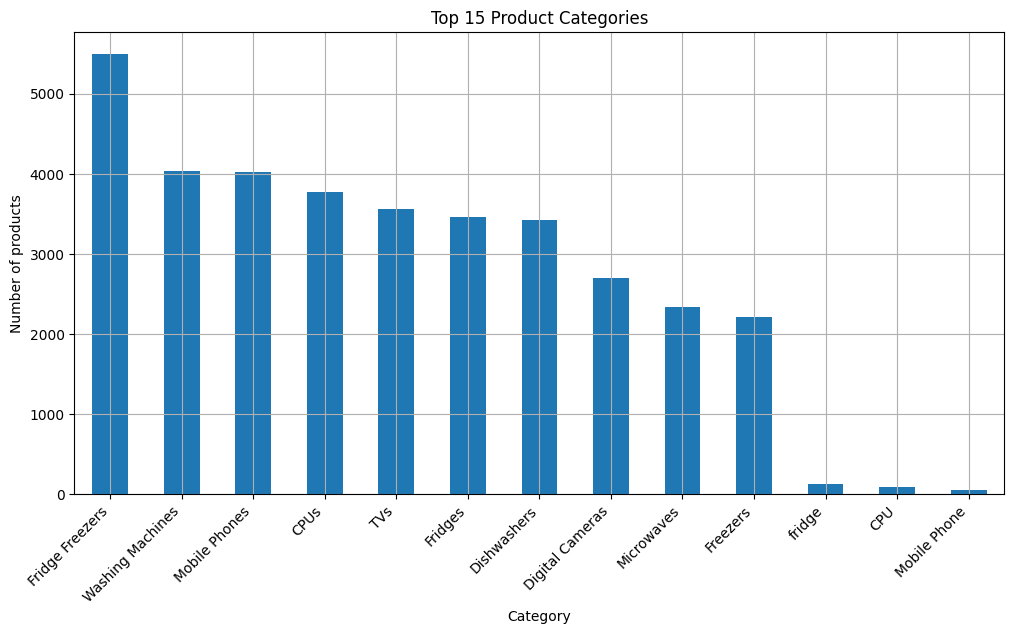

In [ ]:
import matplotlib.pyplot as plt

top_categories = df[" Category Label"].value_counts().head(15)

plt.figure(figsize=(12, 6))
top_categories.plot(kind="bar")
plt.title("Top 15 Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of products")
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.show()

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

Product Title      172
Merchant Rating    170
_Product Code       95
 Listing Date       59
 Category Label     44
Number_of_Views     14
dtype: int64


In [ ]:
# Clean column names (remove leading/trailing spaces)
df.columns = df.columns.str.strip()

print("Cleaned columns:")
print(df.columns.tolist())

Cleaned columns:
['product ID', 'Product Title', 'Merchant ID', 'Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', 'Listing Date']


In [ ]:
# Keep only the columns we need most
df = df[["Product Title", "Category Label"]].copy()

# Drop rows with missing values in important columns
df = df.dropna(subset=["Product Title", "Category Label"])

# Standardize text columns
df["Product Title"] = df["Product Title"].astype(str).str.strip()
df["Category Label"] = df["Category Label"].astype(str).str.strip()

print("Shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isna().sum())

print("\nUnique categories:", df["Category Label"].nunique())
df.head()

Shape after cleaning: (35096, 2)

Missing values after cleaning:
Product Title     0
Category Label    0
dtype: int64

Unique categories: 13


,Product Title,Category Label
0,apple iphone 8 plus 64gb silver,Mobile Phones
1,apple iphone 8 plus 64 gb spacegrau,Mobile Phones
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,Mobile Phones
3,apple iphone 8 plus 64gb space grey,Mobile Phones
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,Mobile Phones


In [ ]:
print("Category distribution:")
print(df["Category Label"].value_counts())

Category distribution:
Category Label
Fridge Freezers     5470
Washing Machines    4015
Mobile Phones       4002
CPUs                3747
TVs                 3541
Fridges             3436
Dishwashers         3405
Digital Cameras     2689
Microwaves          2328
Freezers            2201
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


In [ ]:
# Create simple text features
df["title_length_chars"] = df["Product Title"].astype(str).str.len()
df["title_word_count"] = df["Product Title"].astype(str).apply(lambda x: len(x.split()))
df["has_digits"] = df["Product Title"].astype(str).str.contains(r"\d").astype(int)

df.head()

,Product Title,Category Label,title_length_chars,title_word_count,has_digits
0,apple iphone 8 plus 64gb silver,Mobile Phones,31,6,1
1,apple iphone 8 plus 64 gb spacegrau,Mobile Phones,35,7,1
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,Mobile Phones,70,13,1
3,apple iphone 8 plus 64gb space grey,Mobile Phones,35,7,1
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,Mobile Phones,54,11,1


In [ ]:
from sklearn.model_selection import train_test_split

X = df[["Product Title", "title_length_chars", "title_word_count", "has_digits"]]
y = df["Category Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain category distribution:")
print(y_train.value_counts(normalize=True).head())

print("\nTest category distribution:")
print(y_test.value_counts(normalize=True).head())

Train shape: (28076, 4)
Test shape: (7020, 4)

Train category distribution:
Category Label
Fridge Freezers     0.155863
Washing Machines    0.114404
Mobile Phones       0.114012
CPUs                0.106782
TVs                 0.100905
Name: proportion, dtype: float64

Test category distribution:
Category Label
Fridge Freezers     0.155840
Washing Machines    0.114387
Mobile Phones       0.114103
CPUs                0.106695
TVs                 0.100855
Name: proportion, dtype: float64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers=[
        ("title_tfidf", TfidfVectorizer(), "Product Title"),
        ("numeric", MinMaxScaler(), ["title_length_chars", "title_word_count", "has_digits"])
    ]
)

logreg_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_logreg = logreg_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))

Accuracy: 0.9556980056980057

Classification Report:
                  precision    recall  f1-score   support

             CPU       0.00      0.00      0.00        17
            CPUs       0.98      1.00      0.99       749
 Digital Cameras       0.99      0.99      0.99       538
     Dishwashers       0.93      0.96      0.94       681
        Freezers       0.99      0.93      0.96       440
 Fridge Freezers       0.95      0.94      0.94      1094
         Fridges       0.87      0.91      0.89       687
      Microwaves       0.99      0.96      0.98       466
    Mobile Phone       0.00      0.00      0.00        11
   Mobile Phones       0.97      0.99      0.98       801
             TVs       0.97      1.00      0.98       708
Washing Machines       0.95      0.95      0.95       803
          fridge       0.00      0.00      0.00        25

        accuracy                           0.96      7020
       macro avg       0.74      0.74      0.74      7020
    weighted avg 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


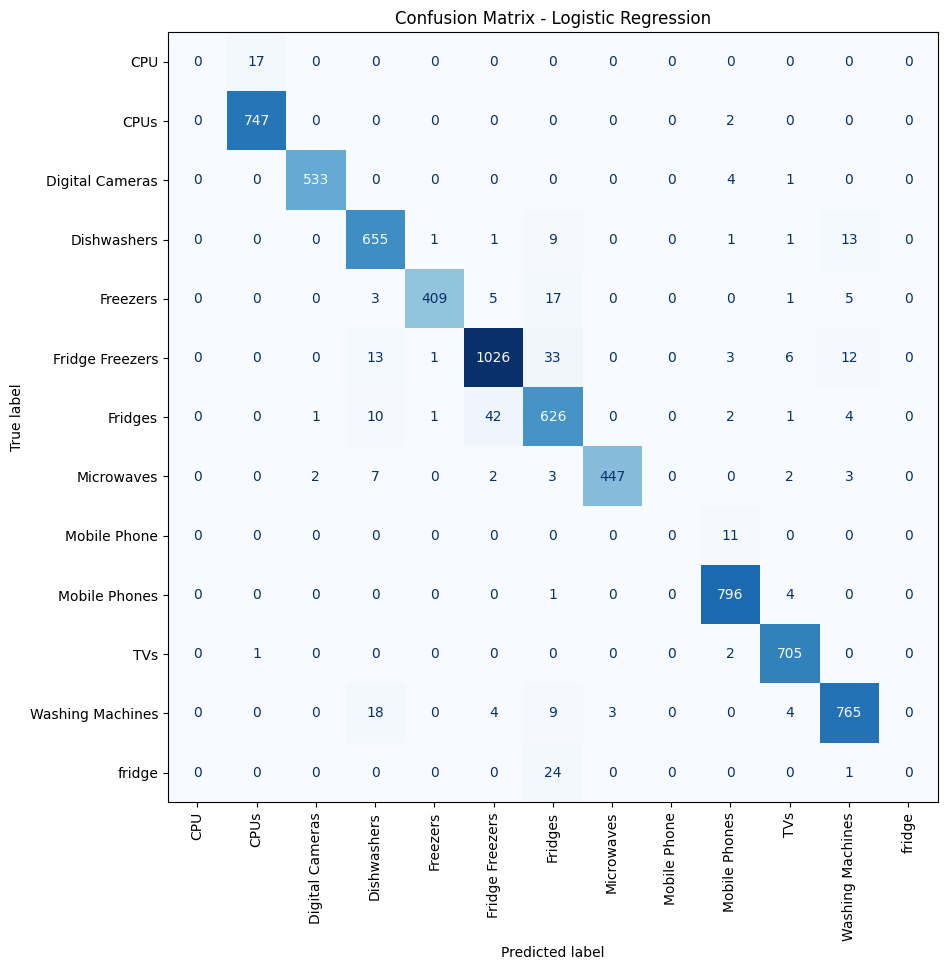

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logreg, labels=logreg_pipeline.classes_)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg_pipeline.classes_)
disp.plot(ax=ax, xticks_rotation=90, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", MultinomialNB())
])

nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report - Naive Bayes:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9086894586894587

Classification Report - Naive Bayes:
                  precision    recall  f1-score   support

             CPU       0.00      0.00      0.00        17
            CPUs       0.97      1.00      0.98       749
 Digital Cameras       0.99      1.00      0.99       538
     Dishwashers       0.99      0.93      0.96       681
        Freezers       0.99      0.37      0.54       440
 Fridge Freezers       0.69      0.99      0.81      1094
         Fridges       0.88      0.75      0.81       687
      Microwaves       1.00      0.95      0.97       466
    Mobile Phone       0.00      0.00      0.00        11
   Mobile Phones       0.98      0.99      0.98       801
             TVs       0.99      0.99      0.99       708
Washing Machines       0.98      0.96      0.97       803
          fridge       0.00      0.00      0.00        25

        accuracy                           0.91      7020
       macro avg       0.73      0.69      0.69  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.svm import LinearSVC

svc_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LinearSVC())
])

svc_pipeline.fit(X_train, y_train)
y_pred_svc = svc_pipeline.predict(X_test)

print("Linear SVC Accuracy:", accuracy_score(y_test, y_pred_svc))
print("\nClassification Report - Linear SVC:")
print(classification_report(y_test, y_pred_svc))

Linear SVC Accuracy: 0.9666666666666667

Classification Report - Linear SVC:
                  precision    recall  f1-score   support

             CPU       0.00      0.00      0.00        17
            CPUs       0.98      1.00      0.99       749
 Digital Cameras       0.99      1.00      1.00       538
     Dishwashers       0.95      0.97      0.96       681
        Freezers       0.99      0.97      0.98       440
 Fridge Freezers       0.97      0.96      0.96      1094
         Fridges       0.90      0.93      0.92       687
      Microwaves       0.99      0.98      0.98       466
    Mobile Phone       0.00      0.00      0.00        11
   Mobile Phones       0.98      1.00      0.99       801
             TVs       0.98      1.00      0.99       708
Washing Machines       0.96      0.96      0.96       803
          fridge       0.00      0.00      0.00        25

        accuracy                           0.97      7020
       macro avg       0.75      0.75      0.75    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_logreg),
    "Multinomial Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "Linear SVC": accuracy_score(y_test, y_pred_svc)
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

results_df

,Model,Accuracy
0,Linear SVC,0.966667
1,Logistic Regression,0.955698
2,Multinomial Naive Bayes,0.908689


In [ ]:
import os
import joblib
from sklearn.svm import LinearSVC

# Use full cleaned dataset
X_full = df[["Product Title", "title_length_chars", "title_word_count", "has_digits"]]
y_full = df["Category Label"]

# Final preprocessor
final_preprocessor = ColumnTransformer(
    transformers=[
        ("title_tfidf", TfidfVectorizer(), "Product Title"),
        ("numeric", MinMaxScaler(), ["title_length_chars", "title_word_count", "has_digits"])
    ]
)

# Final pipeline with best model
final_model = Pipeline([
    ("preprocessing", final_preprocessor),
    ("classifier", LinearSVC())
])

# Train on full dataset
final_model.fit(X_full, y_full)

# Save model
os.makedirs("model", exist_ok=True)
joblib.dump(final_model, "model/category_model.pkl")

print("Final model trained and saved as 'model/category_model.pkl'")

Final model trained and saved as 'model/category_model.pkl'


In [ ]:
from google.colab import files
files.download("model/category_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>